# Tutorial 7 – SED Fitting and Modelling

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from qsosed import SED
from astropy import units as u
import os

plt.style.use('seaborn-v0_8-deep')
plt.rcParams['font.size'] = 14

## AGN SED fitting with AGNfitter

Optical Star-Forming rate vs AGN luminosity (dereddened) vs AGN fraction: 

$\mathrm{SFR_{opt}}$ vs $\mathrm{L_{BB,dered}}(0.1–1\mu\mathrm{m})$ vs $\mathrm{AGNfrac}(0.1–1\mu\mathrm{m})$ — 97.5th percentile

In [2]:
objects = ['Mrk493', 'Mrk876']

# read data and find the global AGNfrac range across all objects
all_frac = []
dfs = {}
for obj in objects:
    file = os.path.join("AGNfitter/OUTPUT", obj, f'posteriors_{obj}.txt')
    dfs[obj] = pd.read_csv(file, delim_whitespace=True)
    all_frac.append(dfs[obj]['AGNfrac(0.1-1)'].values)

all_frac = np.concatenate(all_frac)
vmin, vmax = all_frac.min(), all_frac.max()
pad = 0.05 * (vmax - vmin)
vmin, vmax = vmin - pad, vmax + pad
print(f"AGNfrac range: {vmin:.3f} to {vmax:.3f}")

AGNfrac range: 0.736 to 0.980


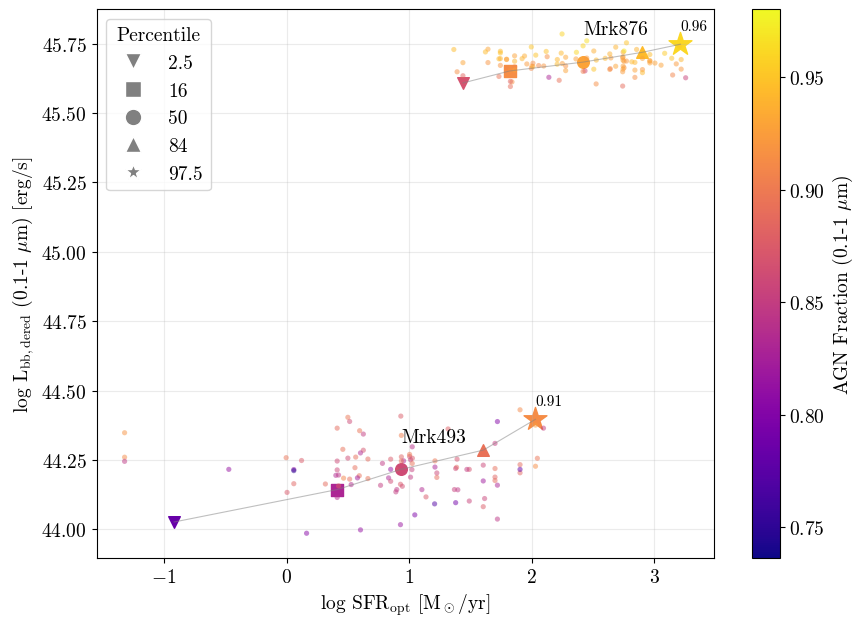

In [3]:
percentiles = [2.5, 16, 50, 84, 97.5]
markers     = ['v', 's', 'o', '^', '*']  
sizes       = [70, 70, 70, 70, 300]     

fig, ax = plt.subplots(figsize=(9, 6.5))


for obj, df in dfs.items():

    logsfr = np.log10(df['SFR_opt'])
    lbb    = df['Lbbdered(0.1-1)']
    frac   = df['AGNfrac(0.1-1)']

    # every sample, faint 
    ax.scatter(logsfr, lbb, c=frac, cmap='plasma', vmin=vmin, vmax=vmax,
               s=14, alpha=0.50, edgecolor='none', zorder=2)

    # percentile value for each quantity
    x = np.percentile(logsfr, percentiles)
    y = np.percentile(lbb,    percentiles)
    c = np.percentile(frac,   percentiles)

    # connector showing the source's track across percentile levels
    ax.plot(x, y, color='gray', lw=0.8, alpha=0.5)

    for xi, yi, ci, mk, sz in zip(x, y, c, markers, sizes):
        sc = ax.scatter(xi, yi, c=[ci], cmap='plasma', vmin=vmin, vmax=vmax,
                        marker=mk, s=sz)

    # label the object
    ax.annotate(obj, (x[2], y[2]), textcoords="offset points",
                xytext=(0, 20))
    ax.annotate(f"{c[4]:.2f}", (x[4], y[4]), textcoords="offset points",
                xytext=(0, 10),fontsize=11)

# colorbar 
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label(r'AGN Fraction (0.1-1 $\mu$m)')

# legend for percentile levels
legend_handles = [
    Line2D([0], [0], marker=mk, color='w', markerfacecolor='gray', markersize=12, label=f'{p}')
    for mk, p in zip(markers, percentiles)
]
ax.legend(handles=legend_handles, title='Percentile', loc='best')

plt.xlabel(r'log $\mathrm{SFR}_{\mathrm{opt}}$ [M$_\odot$/yr]')
plt.ylabel(r'log $\mathrm{L}_{\mathrm{bb,dered}}$ (0.1-1 $\mu$m) [erg/s]')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

- Both sources are strongly **AGN-dominated** in the optical/UV: AGNfrac(0.1–1) sits at ~0.91 (Mrk493) and ~0.96 (Mrk876) at the 97.5th percentile, meaning the accretion disk, not the host stars, drives the 0.1–1 µm light.
- **Mrk876 is the more luminous AGN** (log L_bb,dered ≈ 45.7 vs ≈ 44.4 for Mrk493) *and* sits in the more strongly star-forming host (higher SFR_opt), consistent with the broad AGN–host co-evolution trend where more luminous AGN tend to live in more actively star-forming galaxies.

## AGN SED modeling using QSOSED

In [4]:
# Fixed radii in Rg units
R_HOT = 10.0    # hot corona radius
R_WARM = 20.0   # warm corona radius

In [5]:
def make_sed(M, mdot, spin, r_hot=R_HOT, r_warm=R_WARM,reprocessing=False):
    """
    Build a qsosed SED with the hot/warm corona radii forced to fixed values.
    """
    sed = SED(M=M, mdot=mdot, spin=spin)

    # Force the fixed radii
    sed.corona_radius = r_hot
    sed.corona_height = min(100.0, r_hot)
    sed.warm_radius = r_warm

    # Recompute quantities that read corona_radius / warm_radius.
    sed.reprocessing = False
    sed.corona_luminosity = sed.corona_compute_luminosity
    sed.reprocessing = reprocessing
    sed.uv_fraction, sed.xray_fraction = sed.compute_uv_and_xray_fraction()

    return sed

In [ ]:
# Define the objects with their parameters
objects = [
    dict(name="Super-Edd NLS1", M=2e6,   mdot=1,  spin=0.9,  dist_Mpc=180),
    dict(name="Ark 120",        M=1.5e8, mdot=0.1,  spin=0.83, dist_Mpc=140),
    dict(name="NGC 5548",       M=6.5e7, mdot=0.03, spin=0.0,  dist_Mpc=72),
]

for obj in objects:
    dist_cm = (obj["dist_Mpc"] * u.Mpc).to(u.cm).value
    sed = make_sed(obj["M"], obj["mdot"], obj["spin"])
    obj["sed"] = sed
    obj["E"] = sed.ENERGY_RANGE_KEV
    obj["disk"] = sed.disk_flux(dist_cm)
    obj["warm"] = sed.warm_flux(dist_cm)
    obj["corona"] = sed.corona_flux(dist_cm)
    obj["total"] = sed.total_flux(dist_cm)

/Users/isaac/miniconda3/envs/agn_fitter/lib/python3.10/site-packages/qsosed/sed.py:65: RuntimeWarning: overflow encountered in exp
  planck_spectrum_exp = np.exp( energy / ( const.k_B *  T))
/Users/isaac/miniconda3/envs/agn_fitter/lib/python3.10/site-packages/qsosed/sed.py:357: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  radial_integral = 2 * np.pi**2 * self.Rg**2 * integrate.quad( lambda r: r * self.disk_spectral_radiance(energy, r), self.warm_radius, self.gravity_radius)[0] # units of 1 / s


### SED Components

- Each SED decomposes into three Comptonization zones (Kubota & Done 2018): the **outer disk** (optical/UV, dashed), the **warm Comptonization region** producing the soft X-ray excess (dash-dot), and the **hot corona** (hard X-ray, dotted).
- The **disk dominates the peak** in all three objects; the warm and corona components are sub-dominant and emerge only at higher energies.
- With Rhot = 10 Rg and Rwarm = 20 Rg held fixed, the *relative* strength of the warm and corona components is set by mass, spin, and mdot rather than by geometry.

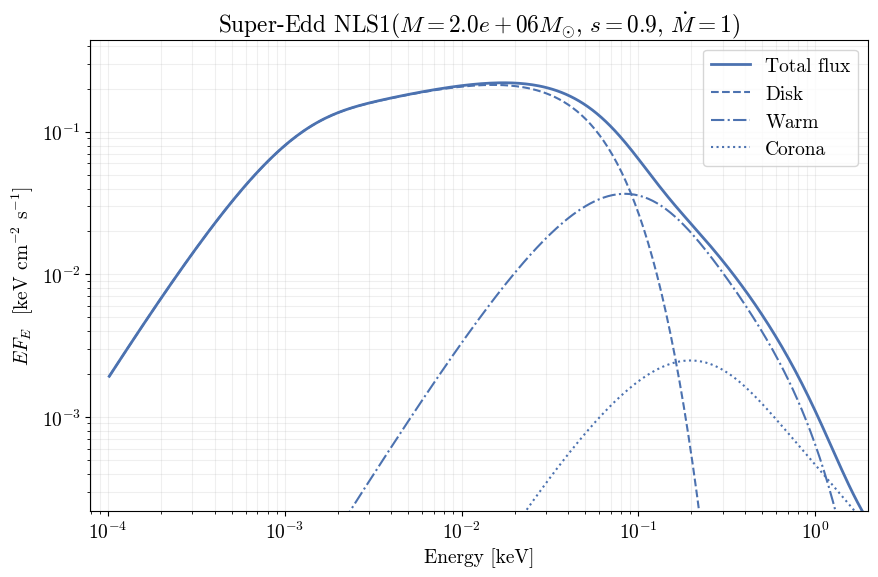

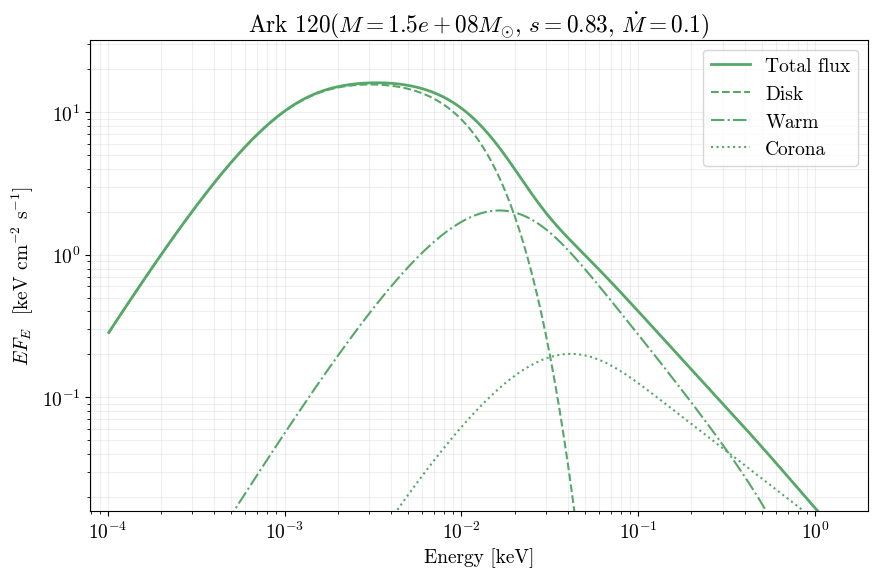

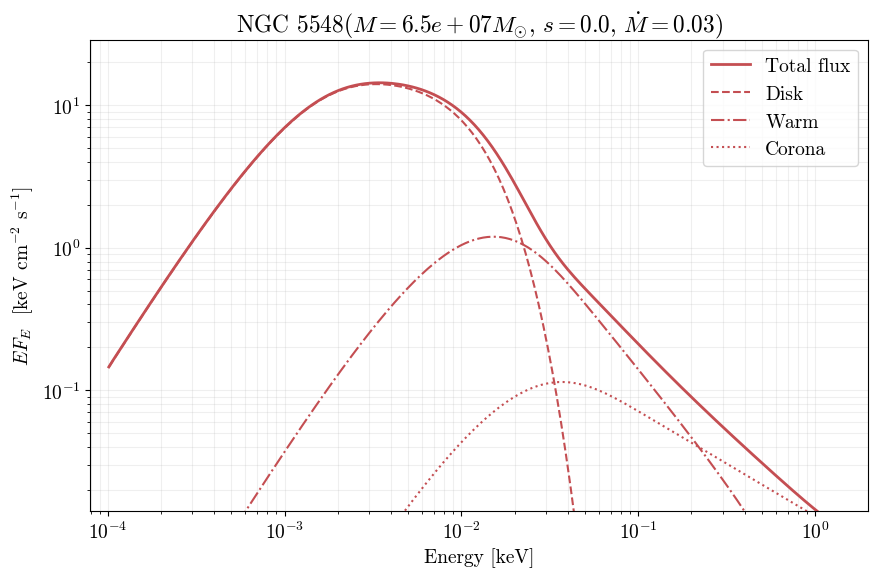

In [ ]:
# Plot SEDs with component breakdown
colors = ['C0', 'C1', 'C2']

for obj,c in zip(objects, colors):
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.plot(obj["E"], obj["total"], color=c, lw=2,
                label=("Total flux"))   
    # light dashed component breakdown for each object
    ax.plot(obj["E"], obj["disk"],   color=c, ls="--",label='Disk')
    ax.plot(obj["E"], obj["warm"],   color=c, ls="-.",label='Warm')
    ax.plot(obj["E"], obj["corona"], color=c, ls=":",label='Corona')

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Energy [keV]")
    ax.set_ylabel(r"$EF_E$  [keV cm$^{-2}$ s$^{-1}$]")
    ax.set_ylim(np.max(obj["total"])* 1e-3, 2*np.max(obj["total"]))
    ax.set_xlim(10**-4.1, 10**0.3)
    ax.set_title(f"{obj['name']}"
                     rf"($M={obj['M']:.1e}M_{{\odot}}$, $s={obj['spin']}$, "
                     rf"$\dot{{M}}={obj['mdot']}$)")
    ax.legend()
    ax.grid(True, which="both", alpha=0.2)
    fig.tight_layout()

### Comparing the three AGN

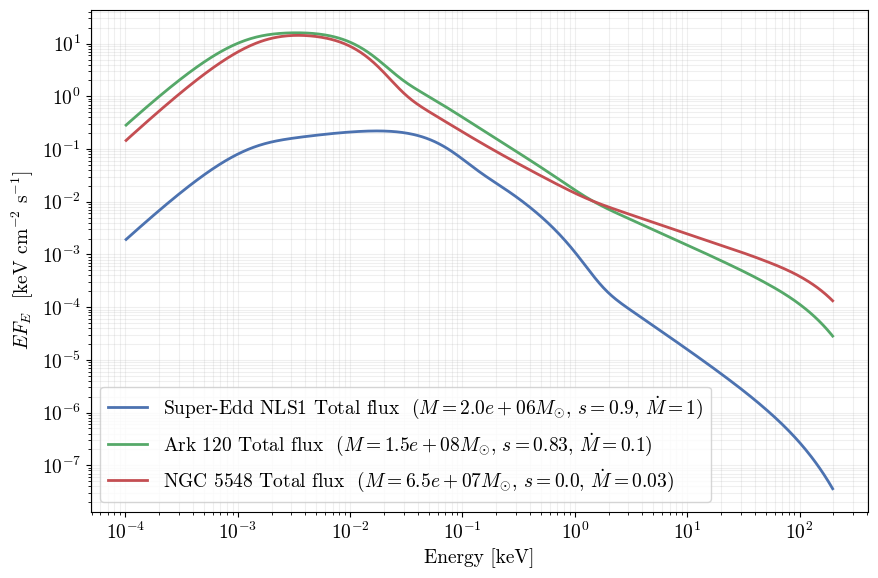

In [ ]:
# Plot just the total SEDs for all objects together
fig, ax = plt.subplots(figsize=(9, 6))

for obj,c in zip(objects, colors):
    ax.plot(obj["E"], obj["total"], color=c, lw=2,
              label=(f"{obj['name']} Total flux  "
                     rf"($M={obj['M']:.1e}M_{{\odot}}$, $s={obj['spin']}$, "
                     rf"$\dot{{M}}={obj['mdot']}$)"))   
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Energy [keV]")
    ax.set_ylabel(r"$EF_E$  [keV cm$^{-2}$ s$^{-1}$]")
    ax.legend()
    ax.grid(True, which="both", alpha=0.2)
    fig.tight_layout()

In [9]:
def effective_T_profile(sed, n=500):
    """Return (r_grid in Rg, T_eff in K) from ISCO out to gravity_radius."""
    r = np.linspace(sed.isco * 1.001, sed.gravity_radius, n)
    T = sed.disk_nt_temperature4(r) ** 0.25   # K
    return r, T

for obj in objects:
    sed = obj["sed"]
    r, T = effective_T_profile(sed)
    T_max = np.nanmax(T)
    r_at_max = r[np.nanargmax(T)]
    obj["T_max"] = T_max
    obj["r_at_T_max"] = r_at_max

In [10]:
print("Effective temperature profile")
for obj in objects:
    print(f'{obj["name"]}: T_eff,max = {obj["T_max"]:.2e} K at r = {obj["r_at_T_max"]:.1f} Rg')

print("\nBolometric luminosity")
for obj in objects:
    print(f'{obj["name"]}: {obj["sed"].bolometric_luminosity:.2e} erg/s')

Effective temperature profile
Super-Edd NLS1: T_eff,max = 3.06e+05 K at r = 12.6 Rg
Ark 120: T_eff,max = 9.93e+04 K at r = 4.2 Rg
NGC 5548: T_eff,max = 5.78e+04 K at r = 9.9 Rg

Bolometric luminosity
Super-Edd NLS1: 2.51e+44 erg/s
Ark 120: 1.89e+45 erg/s
NGC 5548: 2.45e+44 erg/s


**Differences**

- *Super-Edd NLS1* $(M=2\times10^6, \dot{M}=1, s=0.9)$: hottest disk so its peak sits at the highest energy, but the lowest observed flux.
- *Ark 120* $(M=1.5\times10^8, \dot{M}=0.1, s=0.83)$: the most luminous intrinsically and with cooler disk than the Super-Edd.
- *NGC 5548* $(M=6.5\times10^7, \dot{M}=0.03, s=0)$: coolest disk, intermediate mass; L_bol nearly equal to the NLS1's.

In the observed plot, Ark 120 and NGC 5548 appear similar mainly because distance (140 vs 72 Mpc) cancels much of Ark 120's higher intrinsic luminosity; at a common distance Ark 120 sits clearly above NGC 5548:

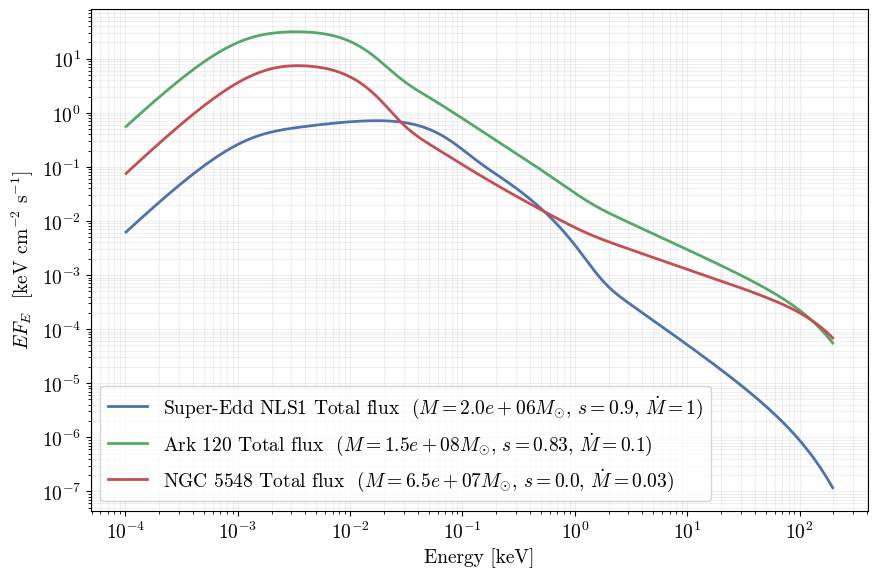

In [ ]:
# Recompute total fluxes at a fixed distance of 100 Mpc to compare intrinsic SED shapes without distance effects
for obj in objects:
    obj['dist_Mpc'] = 100
    dist_cm = (obj["dist_Mpc"] * u.Mpc).to(u.cm).value
    obj["total"] = obj["sed"].total_flux(dist_cm)

fig, ax = plt.subplots(figsize=(9, 6))

for obj,c in zip(objects, colors):
    ax.plot(obj["E"], obj["total"], color=c, lw=2,
              label=(f"{obj['name']} Total flux  "
                     rf"($M={obj['M']:.1e}M_{{\odot}}$, $s={obj['spin']}$, "
                     rf"$\dot{{M}}={obj['mdot']}$)"))   
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Energy [keV]")
    ax.set_ylabel(r"$EF_E$  [keV cm$^{-2}$ s$^{-1}$]")
    ax.legend()
    ax.grid(True, which="both", alpha=0.2)
    fig.tight_layout()

### Isolating the spin effect

**Ark 120: spin effect (M, mdot fixed)**

ISCO radius for spin = 0.0: 6.00 Rg
Max disk effective temperature for spin = 0.0: 6.32e+04 K at r = 10.2 Rg
ISCO radius for spin = 0.5: 4.23 Rg
Max disk effective temperature for spin = 0.5: 7.67e+04 K at r = 7.1 Rg
ISCO radius for spin = 0.9: 2.32 Rg
Max disk effective temperature for spin = 0.9: 1.09e+05 K at r = 3.7 Rg
ISCO radius for spin = 0.998: 1.24 Rg
Max disk effective temperature for spin = 0.998: 1.42e+05 K at r = 2.7 Rg


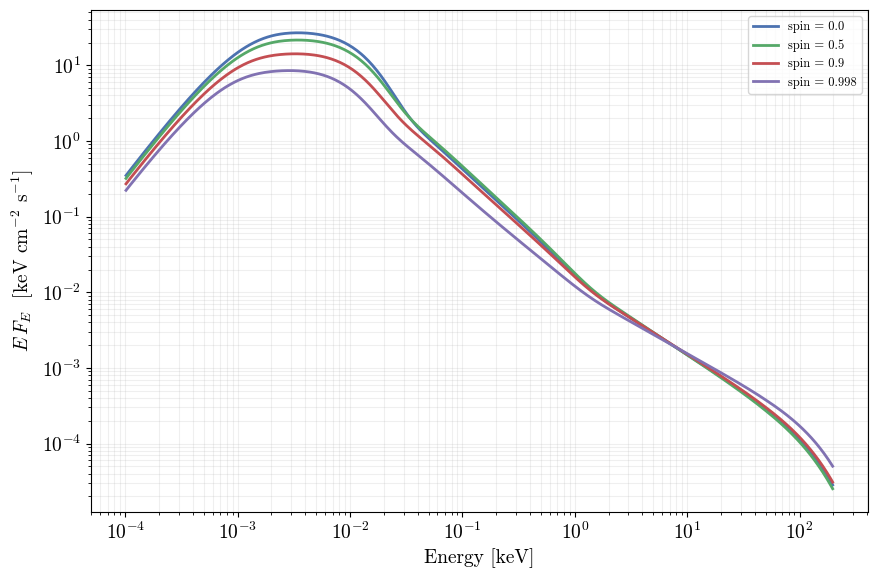

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
dist_cm = (140 * u.Mpc).to(u.cm).value
for spin in [0.0, 0.5, 0.9, 0.998]:
    sed = make_sed(1.5e8, 0.1, spin)
    E = sed.ENERGY_RANGE_KEV
    total = sed.total_flux(dist_cm)
    ax.loglog(E, total, lw=2, label=f"spin = {spin}")
    r, T = effective_T_profile(sed)
    T_max = np.nanmax(T)
    r_at_max = r[np.nanargmax(T)]
    print(f"ISCO radius for spin = {spin}: {sed.isco:.2f} Rg")
    print(f"Max disk effective temperature for spin = {spin}: {T_max:.2e} K at r = {r_at_max:.1f} Rg")
ax.set_xlabel("Energy [keV]")
ax.set_ylabel(r"$E\,F_E$  [keV cm$^{-2}$ s$^{-1}$]")
ax.legend(fontsize=9)
ax.grid(True, which="both", alpha=0.2)
fig.tight_layout()

- Higher spin → smaller ISCO → the disk extends to **smaller, hotter radii**, shifting and raising the UV/EUV peak. The spin = 0.998 case is hottest and most luminous at the peak; spin = 0 is coolest.
- The effect is **concentrated in the UV/soft-X-ray peak region**; at high energies the curves converge, since the corona/warm geometry is held fixed.

### Mass vs temperature scaling

**NGC 5548: mass scaling (mdot, spin fixed)**

Max disk effective temperature for M = 6.50e+07 M_sun: 5.79e+04 K at r = 9.5 Rg
Max disk effective temperature for M = 6.50e+08 M_sun: 3.25e+04 K at r = 9.5 Rg
Max disk effective temperature for M = 6.50e+09 M_sun: 1.83e+04 K at r = 9.5 Rg


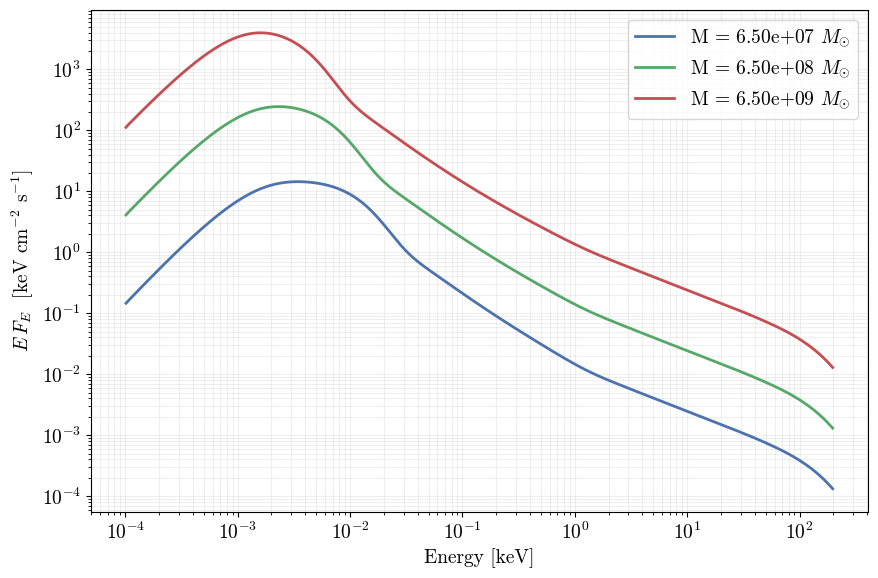

In [13]:
fig, ax = plt.subplots(figsize=(9, 6))
dist_cm = (72 * u.Mpc).to(u.cm).value
for factor in [1, 10, 100]:
    M = 6.5e7 * factor
    sed = make_sed(M, 0.03, 0.0)
    E = sed.ENERGY_RANGE_KEV
    total = sed.total_flux(dist_cm)
    r, T = effective_T_profile(sed,n=1000)
    T_max = np.nanmax(T)
    r_at_max = r[np.nanargmax(T)]
    print(f"Max disk effective temperature for M = {M:.2e} M_sun: {T_max:.2e} K at r = {r_at_max:.1f} Rg")
    ax.loglog(E, total, lw=2, label=rf"M = {M:.2e} $M_{{\odot}}$")
ax.set_xlabel("Energy [keV]")
ax.set_ylabel(r"$E\,F_E$  [keV cm$^{-2}$ s$^{-1}$]")
ax.legend()
ax.grid(True, which="both", alpha=0.2)
fig.tight_layout()

- Increasing $\mathrm{M}$ at fixed $\dot{M}$ and spin pushes the SED peak to **lower energy** (cooler disk: $T \propto M^{−1/4}$) while raising the **total luminosity** (more mass → more available accretion power).
- So the peak moves *down* in energy but *up* in flux, the opposite energy shift to the spin effect.

### Eddington limit & corona reconfiguration

**Super-Edd AGN: accretion rate sweep (M, spin fixed)**

Max disk effective temperature for log(mdot) = 0.0: 5.76e+05 K at r = 3.3 Rg
Max disk effective temperature for log(mdot) = -0.5: 4.32e+05 K at r = 3.6 Rg
Max disk effective temperature for log(mdot) = -1.0: 3.24e+05 K at r = 3.4 Rg
Max disk effective temperature for log(mdot) = -1.5: 2.43e+05 K at r = 3.4 Rg


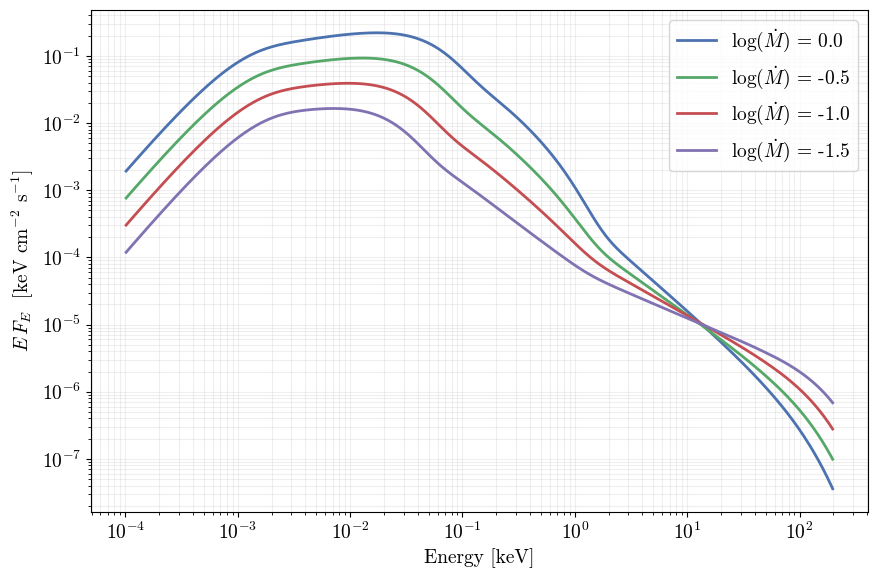

In [14]:
fig, ax = plt.subplots(figsize=(9, 6))
dist_cm = (180 * u.Mpc).to(u.cm).value
for log_mdot in [0.0, -0.5, -1.0, -1.5]:
    mdot = 10.0 ** log_mdot
    sed = make_sed(2e6, mdot, 0.9)
    E = sed.ENERGY_RANGE_KEV
    total = sed.total_flux(dist_cm)
    r, T = effective_T_profile(sed,n=5000)
    T_max = np.nanmax(T)
    r_at_max = r[np.nanargmax(T)]
    print(f"Max disk effective temperature for log(mdot) = {log_mdot}: {T_max:.2e} K at r = {r_at_max:.1f} Rg")
    ax.loglog(E, total, lw=2, label=rf"log($\dot{{M}}$) = {log_mdot}")
ax.set_xlabel("Energy [keV]")
ax.set_ylabel(r"$E\,F_E$  [keV cm$^{-2}$ s$^{-1}$]")
ax.legend()
ax.grid(True, which="both", alpha=0.2)
fig.tight_layout()

- Lowering $\log(\dot{M})$ from 0 to −1.5 **drops the overall luminosity**.
- There is a **crossover near ~10 keV**: at high energies the lower-$\dot{M}$ models actually sit *above* the high-$\dot{M}$ one. As accretion drops, a larger fraction of the power is channelled into the hard corona relative to the disk; the corona "reconfigures" and the hard tail hardens even as the bolometric output falls.

### Conclusion

- $T_{\mathrm{disk}} \propto (\dot{M}/M)^{1/4}$ sets *where* the SED peaks: low-mass, high-mdot objects peak at higher energy.
- $L_{\mathrm{bol}} = \dot{M} L_{\mathrm{Edd}} \propto \dot{M}M$ sets the *intrinsic* normalization, growing with mass.
- These two have opposite mass dependence, so an object can be hot yet faint (the NLS1)
- Spin raises the inner-disk temperature (smaller ISCO), shifting the UV/EUV peak upward.
- Observed flux further depends on distance $(1/d^2)$, which can mask intrinsic differences, as seen with Ark 120 and NGC 5548.

Holding Rhot=10 Rg and Rwarm=20 Rg fixed isolates these mass/mdot/spin effects from changes in the corona geometry